In [3]:
import numpy as np
print("Alao mange du pain !")

Alao mange du pain !


In [5]:
features = np.array([120, 3, 15])
weights = np.array([0.5, 1000, -50])

prediction = np.dot(features, weights)
prediction

np.float64(2310.0)

In [8]:
# 3 maisons différentes, chacune avec 3 features
X = np.array([
    [164, 24, 3],
    [200, 10, 5],
    [90, 30, 1]
])

weights = np.array([5, 200, -80])

predictions = np.dot(X, weights)
predictions

array([5380, 2600, 6370])

In [9]:
from sklearn.linear_model import LinearRegression

# Nos features (comme avant)
X = np.array([
    [164, 24, 3],
    [200, 10, 5],
    [90, 30, 1],
    [140, 15, 2],
    [180, 20, 4]
])

# La vraie réponse pour chaque exemple (le target)
# Imaginons que ça soit le prix d'une maison par exemple
y = np.array([5380, 2600, 6370, 4200, 4800])

# Création du modèle
model = LinearRegression()

# Entraînement — c'est ICI que la magie (gradient descent) opère
model.fit(X, y)

# Les poids que le modèle a appris tout seul
print("Poids appris :", model.coef_)
print("Biais appris :", model.intercept_)

Poids appris : [  16.13045877  168.02647789 -525.29925531]
Biais appris : 421.9784867150893


In [10]:
nouvelle_maison = np.array([[150, 18, 3]])
model.predict(nouvelle_maison)

array([4290.12613772])

In [11]:
np.random.seed(42)  # pour que tu obtiennes les mêmes résultats que moi

n = 100  # 100 maisons

surface = np.random.randint(50, 250, n)
chambres = np.random.randint(1, 6, n)
age = np.random.randint(0, 40, n)

# Le "vrai prix" suit une logique + un peu de bruit aléatoire
bruit = np.random.normal(0, 500, n)
prix = (surface * 20) + (chambres * 3000) - (age * 100) + bruit

X = np.column_stack((surface, chambres, age))
y = prix

print(X[:5])  # affiche les 5 premières lignes
print(y[:5])

[[152   5   1]
 [229   1   1]
 [142   1  27]
 [ 64   1  22]
 [156   1  36]]
[19076.67257901  7553.48732523  3409.80460079  1330.85218131
  2514.27827627]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Taille train :", len(X_train))
print("Taille test :", len(X_test))

Taille train : 80
Taille test : 20


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Poids :", model.coef_)
print("Biais :", model.intercept_)

Poids : [  19.5621324  2977.33278483 -107.37594729]
Biais : 258.55429711635406


In [14]:
predictions = model.predict(X_test)

print("Prédictions :", predictions[:5])
print("Vraies valeurs :", y_test[:5])

Prédictions : [15017.84397715 13655.90218477  2702.8914023  17101.4314617
 11501.4073249 ]
Vraies valeurs : [15628.39812722 12639.84370577  2771.9277572  16936.13258577
 11422.02755111]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("R² :", r2)

MAE : 408.8793443390085
MSE : 286050.60206017055
R² : 0.9894745937403464


In [16]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Charge le dataset (télécharge automatiquement la première fois)
data = fetch_california_housing(as_frame=True)

# as_frame=True nous donne directement un DataFrame Pandas
df = data.frame

# Sauvegarde en vrai fichier CSV dans ton dossier de projet
df.to_csv("housing.csv", index=False)

print("Fichier housing.csv créé !")

Fichier housing.csv créé !


In [17]:
df = pd.read_csv("housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [20]:
# Toutes les colonnes SAUF la target = nos features
X = df.drop("MedHouseVal", axis=1)

# La colonne qu'on veut prédire
y = df["MedHouseVal"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner
model = LinearRegression()
model.fit(X_train, y_train)

# Prédire
predictions = model.predict(X_test)

# Évaluer
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("R² :", r2)

MAE : 0.533200130495656
R² : 0.5757877060324512


In [22]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

predictions_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, predictions_rf)
r2_rf = r2_score(y_test, predictions_rf)

print("MAE (Random Forest) :", mae_rf)
print("R² (Random Forest) :", r2_rf)

MAE (Random Forest) : 0.32773108008720936
R² (Random Forest) : 0.8046244867176197


In [25]:
import pandas as pd

data = {
    "texte": [
        "salut",
        "bonjour",
        "bonsoir",
        "coucou",
        "hey",
        "comment tu vas",
        "comment vas-tu",
        "comment te portes-tu",
        "ça va bien ?",
        "tu vas bien ?",
        "au revoir",
        "à bientôt",
        "bye",
        "je m'en vais",
        "salut, à plus",
        "yo",
        "quelle heure est-il",
        "il est quelle heure",
        "tu as l'heure ?",
        "c'est quelle heure là"
    ],
    "intention": [
        "salutation",
        "salutation",
        "salutation",
        "salutation",
        "salutation",
        "question_sante",
        "question_sante",
        "question_sante",
        "question_sante",
        "question_sante",
        "au_revoir",
        "au_revoir",
        "au_revoir",
        "au_revoir",
        "au_revoir",
        "salutation",
        "question_heure",
        "question_heure",
        "question_heure",
        "question_heure"
    ]
}

df = pd.DataFrame(data)
df

,texte,intention
0,salut,salutation
1,bonjour,salutation
2,bonsoir,salutation
3,coucou,salutation
4,hey,salutation
5,comment tu vas,question_sante
6,comment vas-tu,question_sante
7,comment te portes-tu,question_sante
8,ça va bien ?,question_sante
9,tu vas bien ?,question_sante


In [26]:
print(len(data["texte"]), len(data["intention"]))
print(df.shape)
print(df["intention"].value_counts())

20 20
(20, 2)
intention
salutation        6
question_sante    5
au_revoir         5
question_heure    4
Name: count, dtype: int64


In [27]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texte"])

# Le vocabulaire appris (tous les mots uniques trouvés dans tes 20 phrases)
print("Vocabulaire :")
print(vectorizer.get_feature_names_out())
print()

# Les vecteurs (un tableau de nombres par phrase)
print("Vecteurs :")
print(X.toarray())
print()

# Pour mieux visualiser, on peut mettre ça dans un DataFrame
df_vecteurs = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_vecteurs.insert(0, "texte_original", df["texte"])
df_vecteurs

Vocabulaire :
['as' 'au' 'bien' 'bientôt' 'bonjour' 'bonsoir' 'bye' 'comment' 'coucou'
 'en' 'est' 'heure' 'hey' 'il' 'je' 'là' 'plus' 'portes' 'quelle' 'revoir'
 'salut' 'te' 'tu' 'va' 'vais' 'vas' 'yo' 'ça']

Vecteurs :
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0

,texte_original,as,au,bien,bientôt,bonjour,bonsoir,bye,comment,coucou,...,quelle,revoir,salut,te,tu,va,vais,vas,yo,ça
0,salut,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,bonjour,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,bonsoir,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,coucou,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,hey,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,comment tu vas,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
6,comment vas-tu,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
7,comment te portes-tu,0,0,0,0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
8,ça va bien ?,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
9,tu vas bien ?,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df["intention"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Prédictions :", list(predictions))
print("Vraies valeurs :", list(y_test))

Prédictions : ['au_revoir', 'question_heure', 'au_revoir', 'au_revoir', 'au_revoir', 'question_sante']
Vraies valeurs : ['salutation', 'question_heure', 'salutation', 'salutation', 'question_sante', 'question_sante']


In [33]:
from sklearn.metrics import accuracy_score

print("Précision :", accuracy_score(y_test, predictions))

Précision : 0.9


In [34]:
import pandas as pd

exemples = {
    "salutation": [
        "salut", "salut !", "slt", "coucou", "coucou !", "bonjour", "bonjour !", "bjr",
        "bonsoir", "bsr", "hello", "hey", "yo", "wesh", "wesh alors", "allo", "cc",
        "cc toi", "salut ça va", "hey toi", "hello toi", "bonjour à toi", "re", "rebonjour",
        "coucou toi", "yo la famille", "salut la compagnie", "hé", "hé toi",
        "bien le bonjour", "salutations", "bien le bonjour à toi", "hola", "hi",
        "wsh", "wesh frero", "yo mec", "coucou vous", "bonjour tout le monde",
        "salut tout le monde", "hey vous", "bonsoir à tous", "bonjour madame",
        "bonjour monsieur", "salut mon pote", "coucou ma belle", "hey ma chérie",
        "yo la team", "salut la team", "wesh la fam"
    ],
    "question_sante": [
        "comment tu vas", "comment vas-tu", "comment allez-vous", "comment vous allez",
        "ça va ?", "ça va toi ?", "tu vas bien ?", "vous allez bien ?", "comment te sens-tu",
        "comment te portes-tu", "comment se passe ta journée", "comment se passe ta soirée",
        "ça roule ?", "ça baigne ?", "tout va bien ?", "tu tiens le coup ?",
        "comment ça se passe", "comment ça va aujourd'hui", "tu vas comment",
        "ça va bien ou quoi", "ça gaze ?", "la forme ?", "en forme ?", "ça va la santé",
        "tu te sens comment", "comment tu te sens aujourd'hui", "ça va pas trop dur",
        "tu vas comment aujourd'hui", "quoi de neuf", "quoi de beau", "du nouveau ?",
        "ça se passe comment pour toi", "comment se déroule ta journée",
        "tu es en forme ?", "tout roule ?", "ça va la forme", "comment vous sentez-vous",
        "comment se porte ta santé", "ça va toujours", "toujours en forme ?",
        "comment se passe ta semaine", "comment va la vie", "comment va",
        "la vie va comment", "ça va bien la santé", "tu vas bien toi",
        "ça va bien de ton côté", "ça va de ton côté", "comment ça se passe pour toi"
    ],
    "au_revoir": [
    "au revoir", "à plus", "à plus tard", "bye", "bye bye", "à bientôt", "à demain",
    "à ce soir", "à la prochaine", "je dois y aller", "faut que j'y aille",
    "bonne nuit", "bonne soirée", "bonne journée", "je m'en vais", "je pars",
    "je te laisse", "on se reparle plus tard", "ciao", "tchao",
    "adieu", "à tout à l'heure", "à tout de suite", "je file", "faut y aller",
    "je dois partir", "on se voit plus tard", "à la prochaine fois",
    "bon je te laisse", "allez je file", "à un de ces jours", "bonne continuation",
    "prends soin de toi", "à très vite", "on se reparle bientôt",
    "je vais devoir filer", "désolé je dois y aller", "bon courage à plus",
    "je te dis à bientôt", "allez bye", "ok je te laisse",
    "faut que je parte", "je dois filer", "à une prochaine fois", "bon week-end",
    "bonne fin de journée", "à la revoyure", "et à bientôt"
    ],
    "question_heure": [
        "quelle heure est-il", "il est quelle heure", "tu as l'heure", "t'as l'heure",
        "tu as l'heure stp", "quelle heure il est", "tu sais quelle heure il est",
        "il est quelle heure là", "c'est quelle heure", "c'est quelle heure là",
        "quelle heure on est", "tu connais l'heure", "tu as pas l'heure",
        "sais-tu l'heure qu'il est", "quelle est l'heure actuelle",
        "il est quelle heure maintenant", "tu peux me dire l'heure", "dis-moi l'heure",
        "l'heure s'il te plaît", "quelle heure il fait", "tu as l'heure sur toi",
        "il est quelle heure chez toi", "quelle heure il est là-bas", "tu me dis l'heure",
        "peux-tu me donner l'heure", "quelle heure il est déjà", "sais-tu l'heure",
        "il doit être quelle heure", "on est à quelle heure", "l'heure qu'il est",
        "dis l'heure", "tu as quelle heure toi", "il est quelle heure exactement",
        "tu peux voir l'heure", "il est quelle heure stp", "à quelle heure on est",
        "quelle heure il se fait", "tu regardes l'heure", "l'heure actuelle c'est quoi",
        "c'est quelle heure exactement", "il fait quelle heure",
        "tu sais l'heure qu'il est là", "quelle heure affiche ton téléphone",
        "l'heure qu'il est stp", "dis-moi quelle heure il est",
        "il est quelle heure chef", "il est quelle heure frero",
        "tu peux checker l'heure", "quelle heure ta montre affiche",
        "il est quelle heure au juste"
    ]
}

# On assemble tout automatiquement, sans risque de désalignement
textes = []
intentions = []
for intention, phrases in exemples.items():
    textes.extend(phrases)
    intentions.extend([intention] * len(phrases))

df = pd.DataFrame({"texte": textes, "intention": intentions})

print(df.shape)
print(df["intention"].value_counts())

(197, 2)
intention
salutation        50
question_heure    50
question_sante    49
au_revoir         48
Name: count, dtype: int64


In [35]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Vectorisation
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texte"])
y = df["intention"]

print("Taille du vocabulaire :", len(vectorizer.get_feature_names_out()))

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entraînement
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Évaluation
predictions = model.predict(X_test)
print("Précision :", accuracy_score(y_test, predictions))

Taille du vocabulaire : 173
Précision : 0.9


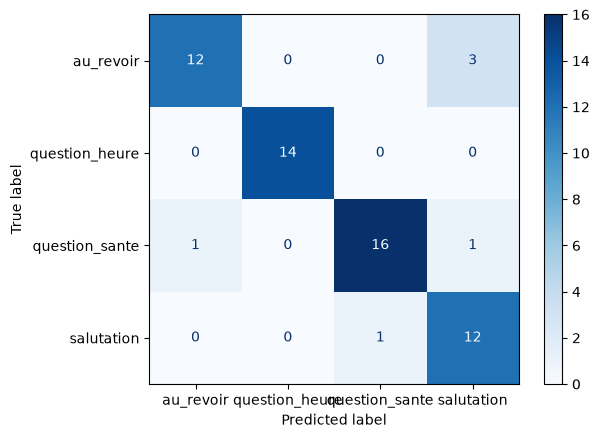

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = model.classes_
cm = confusion_matrix(y_test, predictions, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.show()

In [38]:
import numpy as np

mots = vectorizer.get_feature_names_out()
classes = list(model.classes_)

for classe in ["au_revoir", "salutation"]:
    i = classes.index(classe)
    poids = model.coef_[i]
    top_indices = np.argsort(poids)[-15:][::-1]
    print(f"\n--- Mots qui favorisent '{classe}' ---")
    for idx in top_indices:
        print(f"  {mots[idx]} : {poids[idx]:.2f}")


--- Mots qui favorisent 'au_revoir' ---
  je : 0.93
  bonne : 0.92
  bye : 0.88
  prochaine : 0.77
  plus : 0.77
  bientôt : 0.65
  de : 0.60
  faut : 0.56
  aller : 0.52
  demain : 0.49
  ciao : 0.49
  bon : 0.46
  revoyure : 0.46
  fois : 0.42
  revoir : 0.39

--- Mots qui favorisent 'salutation' ---
  salut : 1.01
  bonjour : 0.85
  coucou : 0.78
  hey : 0.73
  wesh : 0.72
  yo : 0.68
  bonsoir : 0.57
  toi : 0.54
  hello : 0.53
  hé : 0.53
  le : 0.41
  slt : 0.39
  wsh : 0.39
  rebonjour : 0.39
  hi : 0.39


In [39]:
import numpy as np

mots = vectorizer.get_feature_names_out()
classes = list(model.classes_)

for classe in ["au_revoir", "salutation"]:
    i = classes.index(classe)
    poids = model.coef_[i]
    top_indices = np.argsort(poids)[-15:][::-1]
    print(f"\n--- Mots qui favorisent '{classe}' ---")
    for idx in top_indices:
        print(f"  {mots[idx]} : {poids[idx]:.2f}")


--- Mots qui favorisent 'au_revoir' ---
  je : 0.93
  bonne : 0.92
  bye : 0.88
  prochaine : 0.77
  plus : 0.77
  bientôt : 0.65
  de : 0.60
  faut : 0.56
  aller : 0.52
  demain : 0.49
  ciao : 0.49
  bon : 0.46
  revoyure : 0.46
  fois : 0.42
  revoir : 0.39

--- Mots qui favorisent 'salutation' ---
  salut : 1.01
  bonjour : 0.85
  coucou : 0.78
  hey : 0.73
  wesh : 0.72
  yo : 0.68
  bonsoir : 0.57
  toi : 0.54
  hello : 0.53
  hé : 0.53
  le : 0.41
  slt : 0.39
  wsh : 0.39
  rebonjour : 0.39
  hi : 0.39


In [40]:
import numpy as np

mots = vectorizer.get_feature_names_out()
classes = list(model.classes_)

def top_mots(classe, n=15):
    i = classes.index(classe)
    poids = model.coef_[i]
    top_indices = np.argsort(poids)[-n:][::-1]
    return set(mots[idx] for idx in top_indices)

mots_au_revoir = top_mots("au_revoir")
mots_salutation = top_mots("salutation")

print("Mots communs entre les deux top listes :", mots_au_revoir & mots_salutation)

Mots communs entre les deux top listes : set()


In [41]:
# On reconstruit un DataFrame de résultats à partir de X_test/y_test
# Il faut retrouver les textes originaux correspondant à X_test

X_train, X_test, y_train, y_test, texte_train, texte_test = train_test_split(
    X, y, df["texte"], test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

resultats = pd.DataFrame({
    "texte": texte_test.values,
    "vraie_intention": y_test.values,
    "prediction": predictions
})

# On affiche uniquement les erreurs
erreurs = resultats[resultats["vraie_intention"] != resultats["prediction"]]
erreurs

,texte,vraie_intention,prediction
8,salut ça va,salutation,question_sante
31,adieu,au_revoir,salutation
34,à très vite,au_revoir,salutation
41,tu tiens le coup ?,question_sante,salutation
53,quoi de neuf,question_sante,au_revoir
54,tchao,au_revoir,salutation


In [42]:
import pandas as pd

exemples = {
    "salutation": [
        "salut", "salut !", "slt", "coucou", "coucou !", "bonjour", "bonjour !", "bjr",
        "bonsoir", "bsr", "hello", "hey", "yo", "wesh", "wesh alors", "allo", "cc",
        "cc toi", "hey toi", "hello toi", "bonjour à toi", "re", "rebonjour",
        "coucou toi", "yo la famille", "salut la compagnie", "hé", "hé toi",
        "bien le bonjour", "salutations", "bien le bonjour à toi", "hola", "hi",
        "wsh", "wesh frero", "yo mec", "coucou vous", "bonjour tout le monde",
        "salut tout le monde", "hey vous", "bonsoir à tous", "bonjour madame",
        "bonjour monsieur", "salut mon pote", "coucou ma belle", "hey ma chérie",
        "yo la team", "salut la team", "wesh la fam", "salut ça faisait longtemps",
        "hey ça faisait un bail", "coucou du matin", "bonjour du matin",
        "salut du soir", "bonsoir tout le monde", "hey salut", "coucou hello",
        "yo yo", "wesh la compagnie", "salut vous deux", "bonjour vous deux",
    ],
    "question_sante": [
        "comment tu vas", "comment vas-tu", "comment allez-vous", "comment vous allez",
        "ça va ?", "ça va toi ?", "tu vas bien ?", "vous allez bien ?", "comment te sens-tu",
        "comment te portes-tu", "comment se passe ta journée", "comment se passe ta soirée",
        "ça roule ?", "ça baigne ?", "tout va bien ?", "tu tiens le coup ?",
        "comment ça se passe", "comment ça va aujourd'hui", "tu vas comment",
        "ça va bien ou quoi", "ça gaze ?", "la forme ?", "en forme ?", "ça va la santé",
        "tu te sens comment", "comment tu te sens aujourd'hui", "ça va pas trop dur",
        "tu vas comment aujourd'hui", "quoi de neuf", "quoi de beau", "du nouveau ?",
        "ça se passe comment pour toi", "comment se déroule ta journée",
        "tu es en forme ?", "tout roule ?", "ça va la forme", "comment vous sentez-vous",
        "comment se porte ta santé", "ça va toujours", "toujours en forme ?",
        "comment se passe ta semaine", "comment va la vie", "comment va",
        "la vie va comment", "ça va bien la santé", "tu vas bien toi",
        "ça va bien de ton côté", "ça va de ton côté", "comment ça se passe pour toi",
        "quoi de neuf toi", "quoi de neuf chez toi", "quoi de neuf aujourd'hui",
        "tu tiens le coup en ce moment", "tu tiens bon ?", "ça tient le coup ?",
        "comment tu te portes", "tu te portes comment", "ça va niveau santé",
        "ça va la santé en ce moment", "comment se passe ta vie", "la santé ça va ?",
        "et la santé ?", "et toi ça va ?",
    ],
    "au_revoir": [
        "au revoir", "à plus", "à plus tard", "bye", "bye bye", "à bientôt", "à demain",
        "à ce soir", "à la prochaine", "je dois y aller", "faut que j'y aille",
        "bonne nuit", "bonne soirée", "bonne journée", "je m'en vais", "je pars",
        "je te laisse", "on se reparle plus tard", "ciao", "tchao",
        "adieu", "à tout à l'heure", "à tout de suite", "je file", "faut y aller",
        "je dois partir", "on se voit plus tard", "à la prochaine fois",
        "bon je te laisse", "allez je file", "à un de ces jours", "bonne continuation",
        "prends soin de toi", "à très vite", "on se reparle bientôt",
        "je vais devoir filer", "désolé je dois y aller", "bon courage à plus",
        "je te dis à bientôt", "allez bye", "ok je te laisse",
        "faut que je parte", "je dois filer", "à une prochaine fois", "bon week-end",
        "bonne fin de journée", "à la revoyure", "et à bientôt",
        "adieu alors", "adieu mon ami", "tchao tchao", "tchao alors", "ciao ciao",
        "à très bientôt", "à très vite alors", "prends soin de toi hein",
        "bon allez adieu", "je vais y aller", "bon je m'en vais", "bon je pars",
        "bonne route", "bonne fin de soirée", "à plus dans la semaine",
        "à plus dans la journée", "je te quitte", "je dois te quitter",
    ],
    "question_heure": [
        "quelle heure est-il", "il est quelle heure", "tu as l'heure", "t'as l'heure",
        "tu as l'heure stp", "quelle heure il est", "tu sais quelle heure il est",
        "il est quelle heure là", "c'est quelle heure", "c'est quelle heure là",
        "quelle heure on est", "tu connais l'heure", "tu as pas l'heure",
        "sais-tu l'heure qu'il est", "quelle est l'heure actuelle",
        "il est quelle heure maintenant", "tu peux me dire l'heure", "dis-moi l'heure",
        "l'heure s'il te plaît", "quelle heure il fait", "tu as l'heure sur toi",
        "il est quelle heure chez toi", "quelle heure il est là-bas", "tu me dis l'heure",
        "peux-tu me donner l'heure", "quelle heure il est déjà", "sais-tu l'heure",
        "il doit être quelle heure", "on est à quelle heure", "l'heure qu'il est",
        "dis l'heure", "tu as quelle heure toi", "il est quelle heure exactement",
        "tu peux voir l'heure", "il est quelle heure stp", "à quelle heure on est",
        "quelle heure il se fait", "tu regardes l'heure", "l'heure actuelle c'est quoi",
        "c'est quelle heure exactement", "il fait quelle heure",
        "tu sais l'heure qu'il est là", "quelle heure affiche ton téléphone",
        "l'heure qu'il est stp", "dis-moi quelle heure il est",
        "il est quelle heure chef", "il est quelle heure frero",
        "tu peux checker l'heure", "quelle heure ta montre affiche",
        "il est quelle heure au juste", "l'heure svp", "donne-moi l'heure",
        "tu as l'heure exacte", "quelle heure y'a-t-il", "il y a quelle heure",
        "tu sais pas l'heure ?", "l'heure qu'il est là", "quelle heure il se fait là",
    ],
}

# Assemblage automatique (aucun risque de désalignement)
textes = []
intentions = []
for intention, phrases in exemples.items():
    textes.extend(phrases)
    intentions.extend([intention] * len(phrases))

df = pd.DataFrame({"texte": textes, "intention": intentions})

print(df.shape)
print(df["intention"].value_counts())

(248, 2)
intention
au_revoir         66
question_sante    63
salutation        61
question_heure    58
Name: count, dtype: int64


Taille du vocabulaire : 190
Précision : 0.9866666666666667


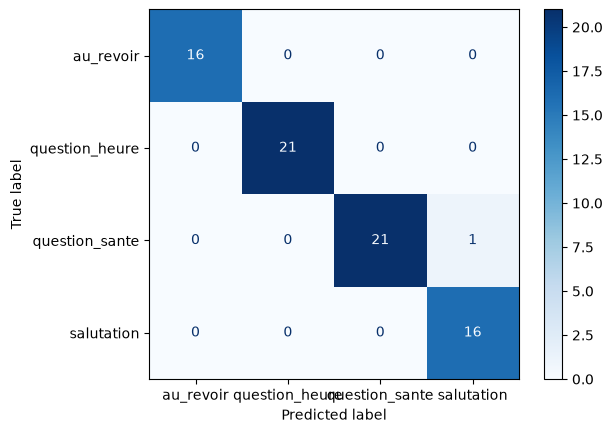

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texte"])
y = df["intention"]

print("Taille du vocabulaire :", len(vectorizer.get_feature_names_out()))

X_train, X_test, y_train, y_test, texte_train, texte_test = train_test_split(
    X, y, df["texte"], test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Précision :", accuracy_score(y_test, predictions))

labels = model.classes_
cm = confusion_matrix(y_test, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.show()

In [44]:
nouvelles_phrases = [
    "salut ça faisait un moment",
    "tu vas comment en ce moment",
    "bon je vais y aller",
    "il est quelle heure là maintenant",
    "wesh quoi de neuf",
    "à la revoyure mon ami",
    "yo comment ça va",
    "l'heure svp",
]

# IMPORTANT : on utilise .transform() et pas .fit_transform()
# car le vocabulaire a déjà été appris — on ne le change pas
X_nouvelles = vectorizer.transform(nouvelles_phrases)

predictions_nouvelles = model.predict(X_nouvelles)

for phrase, prediction in zip(nouvelles_phrases, predictions_nouvelles):
    print(f"'{phrase}' → {prediction}")

'salut ça faisait un moment' → salutation
'tu vas comment en ce moment' → question_sante
'bon je vais y aller' → au_revoir
'il est quelle heure là maintenant' → question_heure
'wesh quoi de neuf' → question_sante
'à la revoyure mon ami' → au_revoir
'yo comment ça va' → question_sante
'l'heure svp' → question_heure


In [45]:
nouvelles_phrases = [
   'salut chef',
   'comment va mon ami ??'
]

# IMPORTANT : on utilise .transform() et pas .fit_transform()
# car le vocabulaire a déjà été appris — on ne le change pas
X_nouvelles = vectorizer.transform(nouvelles_phrases)

predictions_nouvelles = model.predict(X_nouvelles)

for phrase, prediction in zip(nouvelles_phrases, predictions_nouvelles):
    print(f"'{phrase}' → {prediction}")

'salut chef' → salutation
'comment va mon ami ??' → question_sante


In [46]:
import random

reponses = {
    "salutation": [
        "Salut ! Comment je peux t'aider ?",
        "Hey ! Content de te parler.",
        "Coucou, tout va bien ?",
        "Bonjour à toi !",
    ],
    "question_sante": [
        "Ça va super bien, merci ! Et toi ?",
        "Tout roule de mon côté, et toi comment tu vas ?",
        "En pleine forme ! Et toi, ça va ?",
    ],
    "au_revoir": [
        "À bientôt !",
        "Bonne continuation, à plus !",
        "Prends soin de toi, à la prochaine !",
        "Ciao, à très vite !",
    ],
    "question_heure": [
        "Je n'ai pas encore accès à l'heure réelle, mais bientôt !",
        "Cette fonctionnalité arrive bientôt, patience !",
    ],
}

def repondre(phrase):
    X_phrase = vectorizer.transform([phrase])
    intention = model.predict(X_phrase)[0]
    reponse = random.choice(reponses[intention])
    return intention, reponse

# Test
test_phrases = ["salut", "salut", "salut", "comment tu vas", "bye"]
for phrase in test_phrases:
    intention, reponse = repondre(phrase)
    print(f"Toi : {phrase}")
    print(f"Bot ({intention}) : {reponse}\n")

Toi : salut
Bot (salutation) : Bonjour à toi !

Toi : salut
Bot (salutation) : Hey ! Content de te parler.

Toi : salut
Bot (salutation) : Hey ! Content de te parler.

Toi : comment tu vas
Bot (question_sante) : En pleine forme ! Et toi, ça va ?

Toi : bye
Bot (au_revoir) : Prends soin de toi, à la prochaine !



In [47]:
import joblib

joblib.dump(model, "modele_intention.pkl")
joblib.dump(vectorizer, "vectorizer_intention.pkl")
joblib.dump(reponses, "reponses_intention.pkl")

print("Modèle, vectorizer et réponses sauvegardés !")

Modèle, vectorizer et réponses sauvegardés !


In [48]:
import random

# Rechargement depuis zéro (comme si c'était une nouvelle session)
model_charge = joblib.load("modele_intention.pkl")
vectorizer_charge = joblib.load("vectorizer_intention.pkl")
reponses_charge = joblib.load("reponses_intention.pkl")

def repondre_charge(phrase):
    X_phrase = vectorizer_charge.transform([phrase])
    intention = model_charge.predict(X_phrase)[0]
    reponse = random.choice(reponses_charge[intention])
    return intention, reponse

# Test
for phrase in ["salut", "bye", "quelle heure il est", "comment tu vas"]:
    intention, reponse = repondre_charge(phrase)
    print(f"Toi : {phrase}")
    print(f"Bot ({intention}) : {reponse}\n")

Toi : salut
Bot (salutation) : Bonjour à toi !

Toi : bye
Bot (au_revoir) : À bientôt !

Toi : quelle heure il est
Bot (question_heure) : Cette fonctionnalité arrive bientôt, patience !

Toi : comment tu vas
Bot (question_sante) : Tout roule de mon côté, et toi comment tu vas ?



In [49]:
from flask import Flask, request, jsonify
import joblib
import random

app = Flask(__name__)

# Chargement du modèle une seule fois, au démarrage du serveur
model = joblib.load("modele_intention.pkl")
vectorizer = joblib.load("vectorizer_intention.pkl")
reponses = joblib.load("reponses_intention.pkl")

@app.route("/predire", methods=["POST"])
def predire():
    data = request.get_json()
    phrase = data.get("texte", "")

    if not phrase:
        return jsonify({"erreur": "Aucun texte fourni"}), 400

    X_phrase = vectorizer.transform([phrase])
    intention = model.predict(X_phrase)[0]
    reponse = random.choice(reponses[intention])

    return jsonify({
        "texte_recu": phrase,
        "intention": intention,
        "reponse": reponse
    })

if __name__ == "__main__":
    app.run(debug=True, port=5000)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

d:\fatia-ia-ml\venv\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
import pandas as pd

exemples = {
    "salutation": [
        "salut", "salut !", "slt", "coucou", "coucou !", "bonjour", "bonjour !", "bjr",
        "bonsoir", "bsr", "hello", "hey", "yo", "wesh", "wesh alors", "allo", "cc",
        "cc toi", "hey toi", "hello toi", "bonjour à toi", "re", "rebonjour",
        "coucou toi", "yo la famille", "salut la compagnie", "hé", "hé toi",
        "bien le bonjour", "salutations", "bien le bonjour à toi", "hola", "hi",
        "wsh", "wesh frero", "yo mec", "coucou vous", "bonjour tout le monde",
        "salut tout le monde", "hey vous", "bonsoir à tous", "bonjour madame",
        "bonjour monsieur", "salut mon pote", "coucou ma belle", "hey ma chérie",
        "yo la team", "salut la team", "wesh la fam", "salut ça faisait longtemps",
        "hey ça faisait un bail", "coucou du matin", "bonjour du matin",
        "salut du soir", "bonsoir tout le monde", "hey salut", "coucou hello",
        "yo yo", "wesh la compagnie", "salut vous deux", "bonjour vous deux",
    ],
    "question_sante": [
        "comment tu vas", "comment vas-tu", "comment allez-vous", "comment vous allez",
        "ça va ?", "ça va toi ?", "tu vas bien ?", "vous allez bien ?", "comment te sens-tu",
        "comment te portes-tu", "comment se passe ta journée", "comment se passe ta soirée",
        "ça roule ?", "ça baigne ?", "tout va bien ?", "tu tiens le coup ?",
        "comment ça se passe", "comment ça va aujourd'hui", "tu vas comment",
        "ça va bien ou quoi", "ça gaze ?", "la forme ?", "en forme ?", "ça va la santé",
        "tu te sens comment", "comment tu te sens aujourd'hui", "ça va pas trop dur",
        "tu vas comment aujourd'hui", "quoi de neuf", "quoi de beau", "du nouveau ?",
        "ça se passe comment pour toi", "comment se déroule ta journée",
        "tu es en forme ?", "tout roule ?", "ça va la forme", "comment vous sentez-vous",
        "comment se porte ta santé", "ça va toujours", "toujours en forme ?",
        "comment se passe ta semaine", "comment va la vie", "comment va",
        "la vie va comment", "ça va bien la santé", "tu vas bien toi",
        "ça va bien de ton côté", "ça va de ton côté", "comment ça se passe pour toi",
        "quoi de neuf toi", "quoi de neuf chez toi", "quoi de neuf aujourd'hui",
        "tu tiens le coup en ce moment", "tu tiens bon ?", "ça tient le coup ?",
        "comment tu te portes", "tu te portes comment", "ça va niveau santé",
        "ça va la santé en ce moment", "comment se passe ta vie", "la santé ça va ?",
        "et la santé ?", "et toi ça va ?",
    ],
    "au_revoir": [
        "au revoir", "à plus", "à plus tard", "bye", "bye bye", "à bientôt", "à demain",
        "à ce soir", "à la prochaine", "je dois y aller", "faut que j'y aille",
        "bonne nuit", "bonne soirée", "bonne journée", "je m'en vais", "je pars",
        "je te laisse", "on se reparle plus tard", "ciao", "tchao",
        "adieu", "à tout à l'heure", "à tout de suite", "je file", "faut y aller",
        "je dois partir", "on se voit plus tard", "à la prochaine fois",
        "bon je te laisse", "allez je file", "à un de ces jours", "bonne continuation",
        "prends soin de toi", "à très vite", "on se reparle bientôt",
        "je vais devoir filer", "désolé je dois y aller", "bon courage à plus",
        "je te dis à bientôt", "allez bye", "ok je te laisse",
        "faut que je parte", "je dois filer", "à une prochaine fois", "bon week-end",
        "bonne fin de journée", "à la revoyure", "et à bientôt",
        "adieu alors", "adieu mon ami", "tchao tchao", "tchao alors", "ciao ciao",
        "à très bientôt", "à très vite alors", "prends soin de toi hein",
        "bon allez adieu", "je vais y aller", "bon je m'en vais", "bon je pars",
        "bonne route", "bonne fin de soirée", "à plus dans la semaine",
        "à plus dans la journée", "je te quitte", "je dois te quitter",
    ],
    "question_heure": [
        "quelle heure est-il", "il est quelle heure", "tu as l'heure", "t'as l'heure",
        "tu as l'heure stp", "quelle heure il est", "tu sais quelle heure il est",
        "il est quelle heure là", "c'est quelle heure", "c'est quelle heure là",
        "quelle heure on est", "tu connais l'heure", "tu as pas l'heure",
        "sais-tu l'heure qu'il est", "quelle est l'heure actuelle",
        "il est quelle heure maintenant", "tu peux me dire l'heure", "dis-moi l'heure",
        "l'heure s'il te plaît", "quelle heure il fait", "tu as l'heure sur toi",
        "il est quelle heure chez toi", "quelle heure il est là-bas", "tu me dis l'heure",
        "peux-tu me donner l'heure", "quelle heure il est déjà", "sais-tu l'heure",
        "il doit être quelle heure", "on est à quelle heure", "l'heure qu'il est",
        "dis l'heure", "tu as quelle heure toi", "il est quelle heure exactement",
        "tu peux voir l'heure", "il est quelle heure stp", "à quelle heure on est",
        "quelle heure il se fait", "tu regardes l'heure", "l'heure actuelle c'est quoi",
        "c'est quelle heure exactement", "il fait quelle heure",
        "tu sais l'heure qu'il est là", "quelle heure affiche ton téléphone",
        "l'heure qu'il est stp", "dis-moi quelle heure il est",
        "il est quelle heure chef", "il est quelle heure frero",
        "tu peux checker l'heure", "quelle heure ta montre affiche",
        "il est quelle heure au juste", "l'heure svp", "donne-moi l'heure",
        "tu as l'heure exacte", "quelle heure y'a-t-il", "il y a quelle heure",
        "tu sais pas l'heure ?", "l'heure qu'il est là", "quelle heure il se fait là",
    ],
    "remerciement": [
        "merci", "merci !", "merci beaucoup", "merci bien", "mrc", "mrci",
        "je te remercie", "je vous remercie", "merci infiniment", "un grand merci",
        "merci mille fois", "merci pour ça", "merci pour tout", "merci pour ton aide",
        "merci pour votre aide", "merci pour ta réponse", "merci de ta réponse",
        "merci beaucoup pour ton aide", "c'est gentil merci", "trop gentil merci",
        "merci à toi", "merci à vous", "je vous en suis reconnaissant",
        "je t'en suis reconnaissant", "merci du fond du cœur", "merci mon ami",
        "merci ma belle", "merci chef", "merci frero", "merci beaucoup à toi",
        "ça m'aide beaucoup merci", "super merci", "parfait merci", "top merci",
        "merci pour l'info", "merci pour l'information", "merci de m'avoir aidé",
        "merci de m'avoir répondu", "vraiment merci", "merci sincèrement",
        "un grand merci à toi", "merci pour votre temps", "merci pour ton temps",
        "je vous remercie beaucoup", "je te remercie beaucoup", "merci pour votre patience",
        "merci pour ta patience", "merci pour ce que tu fais", "merci pour cette aide précieuse",
        "merci énormément", "merci d'avance", "merci par avance",
    ],
    "demande_aide": [
        "aide-moi", "aidez-moi", "j'ai besoin d'aide", "j'ai besoin de ton aide",
        "j'ai besoin de votre aide", "tu peux m'aider ?", "vous pouvez m'aider ?",
        "je comprends pas", "je comprends rien", "j'ai pas compris",
        "je n'ai pas compris", "peux-tu m'expliquer", "pouvez-vous m'expliquer",
        "explique-moi", "expliquez-moi", "je suis perdu", "je suis perdue",
        "je sais pas quoi faire", "je ne sais pas quoi faire", "comment ça marche",
        "comment ça fonctionne", "je bloque", "je suis bloqué", "je suis bloquée",
        "j'y arrive pas", "je n'y arrive pas", "ça marche pas", "ça fonctionne pas",
        "j'ai un souci", "j'ai un problème", "il y a un problème",
        "je galère", "je galère un peu", "un coup de main stp", "un coup de main s'il te plaît",
        "tu peux m'expliquer comment faire", "comment je fais", "comment je dois faire",
        "je ne comprends pas comment faire", "aide", "help", "au secours",
        "besoin d'assistance", "besoin d'un coup de main", "je suis coincé",
        "je suis coincée", "ça bug", "j'arrive pas à comprendre",
        "comment on fait ça", "tu peux me guider", "guide-moi",
    ],
    "question_bot": [
        "qui es-tu", "qui êtes-vous", "tu es qui", "vous êtes qui", "t'es qui toi",
        "tu es un robot ?", "vous êtes un robot ?", "es-tu une IA", "es-tu un humain",
        "tu es une intelligence artificielle ?", "c'est quoi ton nom", "tu t'appelles comment",
        "comment tu t'appelles", "tu es fait comment", "tu es réel ?",
        "tu es un vrai humain ?", "t'es une machine ?", "t'es un bot ?",
        "tu fonctionnes comment", "comment tu fonctionnes", "qui t'a créé",
        "qui t'a fabriqué", "qui t'a programmé", "tu viens d'où", "d'où viens-tu",
        "tu as été créé par qui", "tu es capable de quoi", "que sais-tu faire",
        "qu'est-ce que tu sais faire", "tu peux faire quoi", "c'est quoi tes capacités",
        "tu es intelligent ?", "es-tu intelligent", "tu penses vraiment ?",
        "tu as des sentiments ?", "es-tu vivant", "tu es vivant ?", "tu as une âme ?",
        "tu es qui exactement", "présente-toi", "présente toi", "dis-moi qui tu es",
        "raconte-moi qui tu es", "tu es un logiciel ?", "t'es un programme ?",
        "tu es basé sur quoi", "sur quoi tu es basé", "tu tournes comment",
    ],
    "confirmation": [
        "oui", "oui !", "ouais", "ouep", "yep", "ok", "d'accord", "daccord",
        "ça marche", "parfait", "exactement", "tout à fait", "c'est ça", "voilà",
        "affirmatif", "certainement", "bien sûr", "évidemment", "carrément",
        "tout à fait d'accord", "oui c'est ça", "oui exactement", "je confirme",
        "c'est exact", "c'est correct", "oui bien sûr", "oui carrément",
        "je suis d'accord", "je suis pour", "oui je veux bien", "d'acc",
        "ok ça marche", "ouais carrément", "clairement", "sans problème",
        "avec plaisir", "volontiers", "oui pourquoi pas", "ok banco", "banco",
        "yes", "yes carrément", "ouep carrément", "ça me va", "ça me convient",
        "je valide", "validé", "top c'est bon", "nickel ça marche", "ok pour moi",
        "oui absolument", "absolument", "totalement d'accord",
    ],
    "negation": [
        "non", "non !", "nan", "nope", "pas du tout", "absolument pas",
        "je ne pense pas", "je pense pas", "non merci", "non je préfère pas",
        "non ça ne va pas", "négatif", "certainement pas", "en aucun cas",
        "pas question", "je ne suis pas d'accord", "je suis pas d'accord",
        "pas vraiment", "pas exactement", "non c'est pas ça", "non c'est faux",
        "c'est faux", "c'est pas correct", "non je ne veux pas", "je refuse",
        "je ne veux pas", "je veux pas", "non pas maintenant", "pas maintenant",
        "non jamais", "jamais de la vie", "je ne crois pas", "je crois pas",
        "non désolé", "désolé mais non", "non pas pour moi", "ça ne me convient pas",
        "ça ne m'arrange pas", "non ça m'arrange pas", "je décline", "je préfère refuser",
        "non impossible", "impossible", "non pas ça", "surtout pas",
        "sûrement pas", "non pas du tout", "aucunement", "pas le moins du monde",
        "non ça ne marche pas", "non ça marche pas", "je ne pense vraiment pas",
    ],
}

# Assemblage automatique (aucun risque de désalignement)
textes = []
intentions = []
for intention, phrases in exemples.items():
    textes.extend(phrases)
    intentions.extend([intention] * len(phrases))

df = pd.DataFrame({"texte": textes, "intention": intentions})

print(df.shape)
print(df["intention"].value_counts())

(504, 2)
intention
au_revoir         66
question_sante    63
salutation        61
question_heure    58
confirmation      53
remerciement      52
negation          52
demande_aide      51
question_bot      48
Name: count, dtype: int64


In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations

vectorizer_check = CountVectorizer()
X_check = vectorizer_check.fit_transform(df["texte"])
mots = vectorizer_check.get_feature_names_out()

# Pour chaque intention, quel est son ensemble de mots utilisés ?
vocab_par_intention = {}
for intention in df["intention"].unique():
    sous_textes = df[df["intention"] == intention]["texte"]
    mots_intention = set()
    for phrase in sous_textes:
        mots_intention.update(phrase.lower().replace("?", "").replace("!", "").split())
    vocab_par_intention[intention] = mots_intention

# On compare chaque paire d'intentions
print("Mots partagés entre paires d'intentions :\n")
for a, b in combinations(vocab_par_intention.keys(), 2):
    communs = vocab_par_intention[a] & vocab_par_intention[b]
    if communs:
        print(f"{a} <-> {b} : {communs}")

Mots partagés entre paires d'intentions :

salutation <-> question_sante : {'ça', 'la', 'toi', 'du', 'bien', 'tout', 'vous', 'le'}
salutation <-> au_revoir : {'soir', 'la', 'à', 'toi', 'mon', 'tout', 'un', 'alors'}
salutation <-> question_heure : {'à', 'frero', 'toi'}
salutation <-> remerciement : {'ça', 'à', 'belle', 'toi', 'du', 'bien', 'un', 'tout', 'mon', 'ma', 'frero', 'vous'}
salutation <-> demande_aide : {'à', 'un', 'ça', 'vous'}
salutation <-> question_bot : {'un', 'vous', 'toi'}
salutation <-> confirmation : {'tout', 'bien', 'ça', 'à'}
salutation <-> negation : {'ça', 'la', 'monde', 'du', 'tout', 'le'}
question_sante <-> au_revoir : {'journée', 'te', 'semaine', 'et', 'allez', 'la', 'toi', 'tout', 'ce', 'bon', 'se', 'soirée', 'de'}
question_sante <-> question_heure : {'chez', 'tu', 'te', 'ton', 'quoi', 'toi', 'ta', 'se', 'pas'}
question_sante <-> remerciement : {'pour', 'tu', 'te', 'trop', 'ça', 'toi', 'du', 'bien', 'tout', 'ce', 'ta', 'de', 'ton', 'vous', 'en'}
question_sante 

Taille du vocabulaire : 347
Précision : 0.8026315789473685


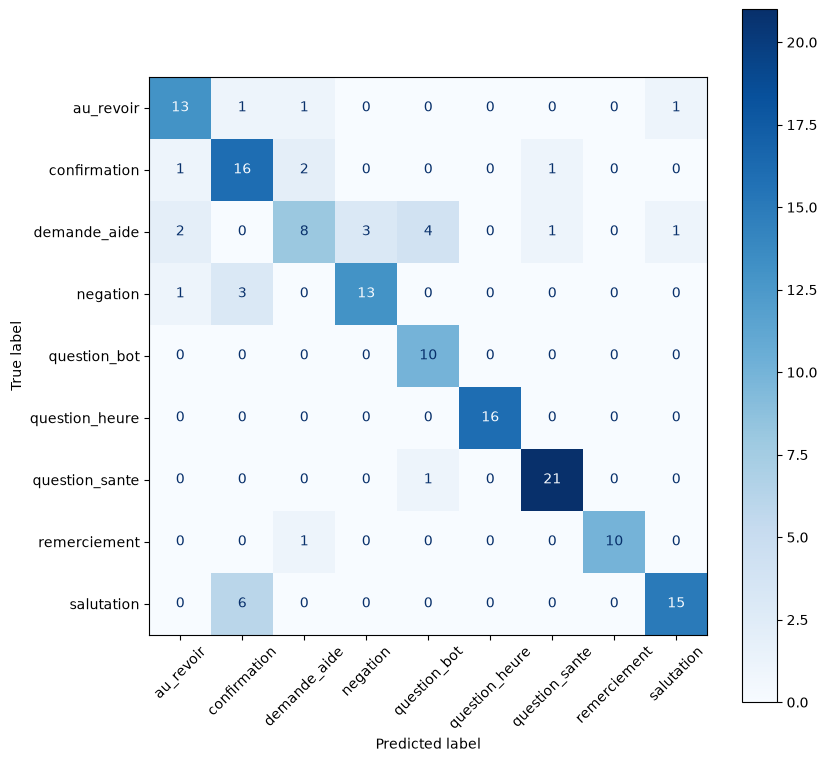

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texte"])
y = df["intention"]

print("Taille du vocabulaire :", len(vectorizer.get_feature_names_out()))

X_train, X_test, y_train, y_test, texte_train, texte_test = train_test_split(
    X, y, df["texte"], test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Précision :", accuracy_score(y_test, predictions))

labels = model.classes_
cm = confusion_matrix(y_test, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.show()

In [4]:
resultats = pd.DataFrame({
    "texte": texte_test.values,
    "vraie_intention": y_test.values,
    "prediction": predictions
})

erreurs = resultats[resultats["vraie_intention"] != resultats["prediction"]]
print(f"{len(erreurs)} erreurs sur {len(resultats)} phrases de test\n")

# On se concentre sur les deux paires les plus problématiques
print("--- salutation confondue avec confirmation ---")
print(erreurs[(erreurs["vraie_intention"] == "salutation") & (erreurs["prediction"] == "confirmation")])

print("\n--- demande_aide (toutes ses erreurs) ---")
print(erreurs[erreurs["vraie_intention"] == "demande_aide"])

print("\n--- negation confondue avec confirmation ---")
print(erreurs[(erreurs["vraie_intention"] == "negation") & (erreurs["prediction"] == "confirmation")])

30 erreurs sur 152 phrases de test

--- salutation confondue avec confirmation ---
         texte vraie_intention    prediction
11         bsr      salutation  confirmation
36         slt      salutation  confirmation
46         wsh      salutation  confirmation
52   rebonjour      salutation  confirmation
103       allo      salutation  confirmation
132       hola      salutation  confirmation

--- demande_aide (toutes ses erreurs) ---
                                 texte vraie_intention      prediction
4                    tu peux m'aider ?    demande_aide    question_bot
15             pouvez-vous m'expliquer    demande_aide      salutation
27           je ne sais pas quoi faire    demande_aide        negation
37   tu peux m'expliquer comment faire    demande_aide    question_bot
84                 peux-tu m'expliquer    demande_aide    question_bot
96                           je galère    demande_aide       au_revoir
99                   tu peux me guider    demande_aide    ques

In [14]:
import pandas as pd

exemples = {
    "salutation": [
        "salut", "salut !", "slt", "slt toi", "coucou", "coucou !", "bonjour", "bonjour !", "bjr",
        "bonsoir", "bsr", "bsr tout le monde", "hello", "hey", "yo", "wesh", "wesh alors", "wesh toi",
        "allo", "allo allo", "cc", "cc toi", "hey toi", "hello toi", "bonjour à toi", "re", "rebonjour",
        "rebonjour à toi", "coucou toi", "yo la famille", "salut la compagnie", "hé", "hé toi",
        "bien le bonjour", "salutations", "bien le bonjour à toi", "hola", "hola amigo", "hi",
        "wsh", "wsh alors", "wesh frero", "yo mec", "coucou vous", "bonjour tout le monde",
        "salut tout le monde", "hey vous", "bonsoir à tous", "bonjour madame",
        "bonjour monsieur", "salut mon pote", "coucou ma belle", "hey ma chérie",
        "yo la team", "salut la team", "wesh la fam", "salut ça faisait longtemps",
        "hey ça faisait un bail", "coucou du matin", "bonjour du matin",
        "salut du soir", "bonsoir tout le monde", "hey salut", "coucou hello",
        "yo yo", "wesh la compagnie", "salut vous deux", "bonjour vous deux",
        "slt les gens", "bsr à toi", "allo c'est moi", "hola tout le monde", "rebonjour vous",
    ],
    "question_sante": [
        "comment tu vas", "comment vas-tu", "comment allez-vous", "comment vous allez",
        "ça va ?", "ça va toi ?", "tu vas bien ?", "vous allez bien ?", "comment te sens-tu",
        "comment te portes-tu", "comment se passe ta journée", "comment se passe ta soirée",
        "ça roule ?", "ça baigne ?", "tout va bien ?", "tu tiens le coup ?",
        "comment ça se passe", "comment ça va aujourd'hui", "tu vas comment",
        "ça va bien ou quoi", "ça gaze ?", "la forme ?", "en forme ?", "ça va la santé",
        "tu te sens comment", "comment tu te sens aujourd'hui", "ça va pas trop dur",
        "tu vas comment aujourd'hui", "quoi de neuf", "quoi de beau", "du nouveau ?",
        "ça se passe comment pour toi", "comment se déroule ta journée",
        "tu es en forme ?", "tout roule ?", "ça va la forme", "comment vous sentez-vous",
        "comment se porte ta santé", "ça va toujours", "toujours en forme ?",
        "comment se passe ta semaine", "comment va la vie", "comment va",
        "la vie va comment", "ça va bien la santé", "tu vas bien toi",
        "ça va bien de ton côté", "ça va de ton côté", "comment ça se passe pour toi",
        "quoi de neuf toi", "quoi de neuf chez toi", "quoi de neuf aujourd'hui",
        "tu tiens le coup en ce moment", "tu tiens bon ?", "ça tient le coup ?",
        "comment tu te portes", "tu te portes comment", "ça va niveau santé",
        "ça va la santé en ce moment", "comment se passe ta vie", "la santé ça va ?",
        "et la santé ?", "et toi ça va ?",
    ],
    "au_revoir": [
        "au revoir", "à plus", "à plus tard", "bye", "bye bye", "à bientôt", "à demain",
        "à ce soir", "à la prochaine", "je dois y aller", "faut que j'y aille",
        "bonne nuit", "bonne soirée", "bonne journée", "je m'en vais", "je pars",
        "je te laisse", "on se reparle plus tard", "ciao", "tchao",
        "adieu", "à tout à l'heure", "à tout de suite", "je file", "faut y aller",
        "je dois partir", "on se voit plus tard", "à la prochaine fois",
        "bon je te laisse", "allez je file", "à un de ces jours", "bonne continuation",
        "prends soin de toi", "à très vite", "on se reparle bientôt",
        "je vais devoir filer", "désolé je dois y aller", "bon courage à plus",
        "je te dis à bientôt", "allez bye", "ok je te laisse",
        "faut que je parte", "je dois filer", "à une prochaine fois", "bon week-end",
        "bonne fin de journée", "à la revoyure", "et à bientôt",
        "adieu alors", "adieu mon ami", "tchao tchao", "tchao alors", "ciao ciao",
        "à très bientôt", "à très vite alors", "prends soin de toi hein",
        "bon allez adieu", "je vais y aller", "bon je m'en vais", "bon je pars",
        "bonne route", "bonne fin de soirée", "à plus dans la semaine",
        "à plus dans la journée", "je te quitte", "je dois te quitter",
    ],
    "question_heure": [
        "quelle heure est-il", "il est quelle heure", "tu as l'heure", "t'as l'heure",
        "tu as l'heure stp", "quelle heure il est", "tu sais quelle heure il est",
        "il est quelle heure là", "c'est quelle heure", "c'est quelle heure là",
        "quelle heure on est", "tu connais l'heure", "tu as pas l'heure",
        "sais-tu l'heure qu'il est", "quelle est l'heure actuelle",
        "il est quelle heure maintenant", "tu peux me dire l'heure", "dis-moi l'heure",
        "l'heure s'il te plaît", "quelle heure il fait", "tu as l'heure sur toi",
        "il est quelle heure chez toi", "quelle heure il est là-bas", "tu me dis l'heure",
        "peux-tu me donner l'heure", "quelle heure il est déjà", "sais-tu l'heure",
        "il doit être quelle heure", "on est à quelle heure", "l'heure qu'il est",
        "dis l'heure", "tu as quelle heure toi", "il est quelle heure exactement",
        "tu peux voir l'heure", "il est quelle heure stp", "à quelle heure on est",
        "quelle heure il se fait", "tu regardes l'heure", "l'heure actuelle c'est quoi",
        "c'est quelle heure exactement", "il fait quelle heure",
        "tu sais l'heure qu'il est là", "quelle heure affiche ton téléphone",
        "l'heure qu'il est stp", "dis-moi quelle heure il est",
        "il est quelle heure chef", "il est quelle heure frero",
        "tu peux checker l'heure", "quelle heure ta montre affiche",
        "il est quelle heure au juste", "l'heure svp", "donne-moi l'heure",
        "tu as l'heure exacte", "quelle heure y'a-t-il", "il y a quelle heure",
        "tu sais pas l'heure ?", "l'heure qu'il est là", "quelle heure il se fait là",
    ],
    "remerciement": [
        "merci", "merci !", "merci beaucoup", "merci bien", "mrc", "mrci",
        "je te remercie", "je vous remercie", "merci infiniment", "un grand merci",
        "merci mille fois", "merci pour ça", "merci pour tout", "merci pour ton aide",
        "merci pour votre aide", "merci pour ta réponse", "merci de ta réponse",
        "merci beaucoup pour ton aide", "c'est gentil merci", "trop gentil merci",
        "merci à toi", "merci à vous", "je vous en suis reconnaissant",
        "je t'en suis reconnaissant", "merci du fond du cœur", "merci mon ami",
        "merci ma belle", "merci chef", "merci frero", "merci beaucoup à toi",
        "ça m'aide beaucoup merci", "super merci", "parfait merci", "top merci",
        "merci pour l'info", "merci pour l'information", "merci de m'avoir aidé",
        "merci de m'avoir répondu", "vraiment merci", "merci sincèrement",
        "un grand merci à toi", "merci pour votre temps", "merci pour ton temps",
        "je vous remercie beaucoup", "je te remercie beaucoup", "merci pour votre patience",
        "merci pour ta patience", "merci pour ce que tu fais", "merci pour cette aide précieuse",
        "merci énormément", "merci d'avance", "merci par avance",
    ],
    "demande_aide": [
        "aide-moi", "aidez-moi", "j'ai besoin d'aide", "j'ai besoin de ton aide",
        "j'ai besoin de votre aide", "tu peux m'aider ?", "vous pouvez m'aider ?",
        "je comprends pas", "je comprends rien", "j'ai pas compris",
        "je n'ai pas compris", "peux-tu m'expliquer", "pouvez-vous m'expliquer",
        "explique-moi", "expliquez-moi", "je suis perdu aide-moi", "je suis perdue aide-moi",
        "je sais pas quoi faire aide-moi", "je ne sais pas quoi faire, aide-moi",
        "comment ça marche explique-moi", "comment ça fonctionne explique-moi",
        "je bloque, tu peux m'aider ?", "je suis bloqué aide-moi", "je suis bloquée aide-moi",
        "j'y arrive pas, aide-moi stp", "je n'y arrive pas, tu peux m'aider ?",
        "ça marche pas aide-moi", "ça fonctionne pas, aide-moi stp",
        "j'ai un souci aide-moi", "j'ai un problème tu peux m'aider",
        "il y a un problème, aide-moi", "je galère, tu peux m'aider ?",
        "je galère un peu, aide-moi", "un coup de main stp", "un coup de main s'il te plaît",
        "tu peux m'expliquer comment faire", "comment je fais, explique-moi",
        "comment je dois faire, aide-moi", "je ne comprends pas comment faire, aide-moi",
        "aide", "help", "au secours", "besoin d'assistance stp", "besoin d'un coup de main",
        "je suis coincé, aide-moi", "je suis coincée, aide-moi",
        "ça bug, aide-moi stp", "ça bug, tu peux m'aider ?",
        "j'arrive pas à comprendre, explique-moi", "comment on fait ça, aide-moi",
        "tu peux me guider stp", "guide-moi s'il te plaît", "j'ai besoin qu'on m'explique",
        "j'ai besoin qu'on m'aide", "peux-tu m'aider avec ça", "aide-moi avec ça stp",
        "je suis largué, aide-moi", "je suis larguée, aide-moi", "j'ai du mal, aide-moi",
        "je n'arrive pas à faire ça, aide-moi", "tu peux m'aider s'il te plaît",
    ],
   "question_bot": [
    "qui es-tu", "qui êtes-vous", "tu es qui", "vous êtes qui", "t'es qui toi",
    "tu es un robot ?", "vous êtes un robot ?", "es-tu une IA", "es-tu un humain",
    "tu es une intelligence artificielle ?", "quel est ton nom", "ton nom c'est quoi",
    "tu t'appelles comment", "comment tu t'appelles toi", "tu es fait comment toi",
    "tu es réel toi ?", "tu es un vrai humain ?", "t'es une machine ?", "t'es un bot ?",
    "tu fonctionnes comment toi", "explique-moi comment tu fonctionnes", "qui t'a créé toi",
    "dis-moi qui t'a créé", "qui t'a fabriqué exactement", "c'est qui qui t'a fabriqué",
    "qui t'a programmé toi", "dis-moi qui t'a programmé", "tu viens d'où toi",
    "d'où viens-tu exactement", "tu as été créé par qui exactement", "tu es capable de quoi toi",
    "que sais-tu faire toi", "quelles sont tes capacités", "parle-moi de tes capacités",
    "tu peux faire quoi toi", "décris-moi tes capacités", "tu es intelligent toi ?",
    "es-tu vraiment intelligent", "tu penses vraiment par toi-même ?",
    "tu as des sentiments toi ?", "es-tu vivant toi", "tu es vivant ou pas ?", "tu as une âme toi ?",
    "tu es qui exactement toi", "présente-toi s'il te plaît", "présente toi à moi",
    "dis-moi qui tu es vraiment", "raconte-moi qui tu es toi", "tu es un logiciel ?",
    "t'es un simple programme ?", "sur quoi tu es basé toi", "tu es basé sur quel modèle",
    "tu tournes avec quelle technologie", "quelle technologie te fait tourner",
    "ton nom c'est comment", "quel est ton nom exactement", "comment on t'appelle toi",
    ],
    "confirmation": [
    "oui c'est bon pour moi", "oui je suis d'accord", "ouais ça marche pour moi",
    "ouep on fait comme ça", "yep c'est parfait", "ok je suis partant",
    "d'accord pour moi", "d'accord ça me va", "ça marche très bien pour moi",
    "parfait ça me convient", "exactement ce que je pensais", "tout à fait d'accord avec toi",
    "c'est exactement ça", "voilà c'est exactement ça", "affirmatif je confirme",
    "certainement oui je suis d'accord", "bien sûr que oui", "évidemment que oui",
    "carrément je suis partant", "tout à fait d'accord avec ça", "oui c'est exactement ça",
    "oui c'est bien ça", "je confirme totalement", "c'est exact ce que tu dis",
    "c'est tout à fait correct", "oui bien sûr je suis d'accord", "oui carrément je valide",
    "je suis complètement d'accord", "je suis pour cette idée", "oui je veux bien participer",
    "d'acc je te suis", "ok ça marche comme prévu", "ouais carrément d'accord",
    "clairement je suis pour", "sans problème je suis partant", "avec plaisir je viens",
    "volontiers j'accepte ça", "oui pourquoi pas je suis partant", "ok banco on y va",
    "banco je suis partant", "yes carrément je suis d'accord", "ouep carrément d'accord avec toi",
    "ça me va très bien", "ça me convient parfaitement", "je valide complètement cette idée",
    "c'est validé de mon côté", "top c'est tout bon pour moi", "nickel ça marche pour moi",
    "ok c'est bon pour moi", "oui absolument je suis d'accord", "totalement d'accord avec toi",
    "je suis à fond partant", "oui ça me semble parfait",
    ],
   "negation": [
    "non", "non !", "nan", "nope", "nope ça marche pas", "pas du tout",
    "absolument pas", "je ne pense pas", "je pense pas", "non merci",
    "non je préfère pas", "non ça ne va pas", "négatif", "certainement pas",
    "en aucun cas", "pas question", "je ne suis pas d'accord", "je suis pas d'accord",
    "pas vraiment", "pas exactement", "non c'est pas ça", "non c'est faux",
    "c'est faux", "c'est pas correct", "non je ne veux pas", "je refuse cette proposition",
    "je ne veux pas", "je veux pas", "non pas maintenant", "pas maintenant",
    "non jamais de la vie", "jamais de la vie je refuse", "je ne crois pas", "je crois pas",
    "non désolé", "désolé mais non", "non pas pour moi", "ça ne me convient pas",
    "ça ne m'arrange pas", "non ça m'arrange pas", "je décline cette offre", "je préfère refuser ça",
    "non impossible pour moi", "impossible, je ne peux pas faire ça", "c'est impossible pour moi",
    "non pas ça", "surtout pas", "sûrement pas", "non pas du tout",
    "je ne suis aucunement d'accord", "c'est aucunement possible", "pas le moins du monde",
    "non ça ne marche pas", "non ça marche pas", "je ne pense vraiment pas",
    "nope ça marche vraiment pas", "c'est totalement impossible", "jamais je n'accepterai ça",
    "je refuse catégoriquement", "c'est non pour moi",
   ],
}

# Assemblage automatique (aucun risque de désalignement)
textes = []
intentions = []
for intention, phrases in exemples.items():
    textes.extend(phrases)
    intentions.extend([intention] * len(phrases))

df = pd.DataFrame({"texte": textes, "intention": intentions})

print(df.shape)
print(df["intention"].value_counts())

(543, 2)
intention
salutation        73
au_revoir         66
question_sante    63
demande_aide      61
negation          60
question_heure    58
question_bot      57
confirmation      53
remerciement      52
Name: count, dtype: int64


Taille du vocabulaire : 378
Précision : 0.901840490797546


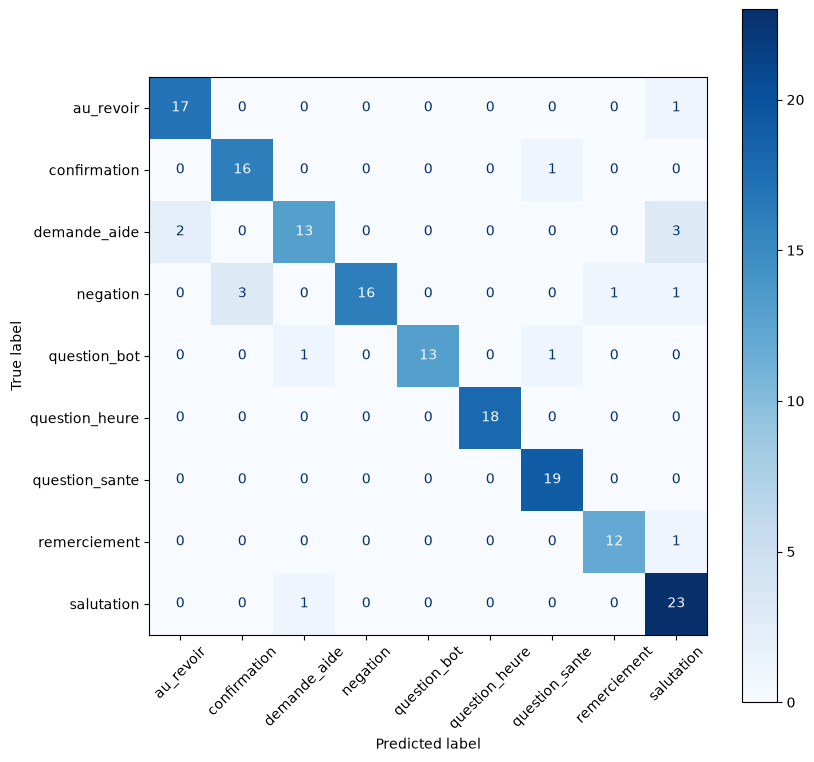

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["texte"])
y = df["intention"]

print("Taille du vocabulaire :", len(vectorizer.get_feature_names_out()))

X_train, X_test, y_train, y_test, texte_train, texte_test = train_test_split(
    X, y, df["texte"], test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Précision :", accuracy_score(y_test, predictions))

labels = model.classes_
cm = confusion_matrix(y_test, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.show()

In [7]:
resultats = pd.DataFrame({
    "texte": texte_test.values,
    "vraie_intention": y_test.values,
    "prediction": predictions
})

erreurs = resultats[resultats["vraie_intention"] != resultats["prediction"]]

print("--- Toutes les phrases confondues AVEC confirmation ---")
print(erreurs[erreurs["prediction"] == "confirmation"])

print("\n--- Toutes les erreurs de negation ---")
print(erreurs[erreurs["vraie_intention"] == "negation"])

--- Toutes les phrases confondues AVEC confirmation ---
                      texte vraie_intention    prediction
8       aucunement possible        negation  confirmation
10                      bsr      salutation  confirmation
26             bon week-end       au_revoir  confirmation
37           allo c'est moi      salutation  confirmation
44      aucunement d'accord        negation  confirmation
88                     allo      salutation  confirmation
96                ça gaze ?  question_sante  confirmation
125             ça baigne ?  question_sante  confirmation
133               allo allo      salutation  confirmation
141                      re      salutation  confirmation
155  hey ça faisait un bail      salutation  confirmation

--- Toutes les erreurs de negation ---
                   texte vraie_intention    prediction
8    aucunement possible        negation  confirmation
25      jamais de la vie        negation     au_revoir
44   aucunement d'accord        negation  c

In [8]:
df["longueur"] = df["texte"].apply(lambda x: len(x.split()))
print(df.groupby("intention")["longueur"].mean().sort_values())

intention
confirmation      2.000000
salutation        2.260274
negation          3.052632
au_revoir         3.136364
remerciement      3.173077
question_bot      3.687500
question_sante    4.095238
question_heure    4.189655
demande_aide      4.213115
Name: longueur, dtype: float64


In [16]:
resultats = pd.DataFrame({
    "texte": texte_test.values,
    "vraie_intention": y_test.values,
    "prediction": predictions
})

erreurs = resultats[resultats["vraie_intention"] != resultats["prediction"]]
print(erreurs[erreurs["vraie_intention"] == "question_bot"])

                                   texte vraie_intention      prediction
18              comment on t'appelle toi    question_bot  question_sante
113  explique-moi comment tu fonctionnes    question_bot    demande_aide


In [17]:
import random

reponses = {
    "salutation": [
        "Salut ! Comment je peux t'aider ?",
        "Hey ! Content de te parler.",
        "Coucou, tout va bien ?",
        "Bonjour à toi !",
    ],
    "question_sante": [
        "Ça va super bien, merci ! Et toi ?",
        "Tout roule de mon côté, et toi comment tu vas ?",
        "En pleine forme ! Et toi, ça va ?",
    ],
    "au_revoir": [
        "À bientôt !",
        "Bonne continuation, à plus !",
        "Prends soin de toi, à la prochaine !",
        "Ciao, à très vite !",
    ],
    "question_heure": [
        "Je n'ai pas encore accès à l'heure réelle, mais bientôt !",
        "Cette fonctionnalité arrive bientôt, patience !",
    ],
    "remerciement": [
        "Avec plaisir !",
        "De rien, c'est normal !",
        "Content d'avoir pu aider !",
        "Pas de souci, à ton service !",
    ],
    "demande_aide": [
        "Bien sûr, dis-moi ce qui te bloque.",
        "Je suis là pour t'aider, explique-moi le souci.",
        "Pas de panique, on va regarder ça ensemble. Qu'est-ce qui coince ?",
    ],
    "question_bot": [
        "Je suis Fatia IA, un assistant conçu pour t'aider dans cette app !",
        "Je suis une intelligence artificielle créée pour discuter avec toi.",
        "Je suis un assistant IA, encore en apprentissage !",
    ],
    "confirmation": [
        "Parfait, on continue comme ça !",
        "Super, c'est noté !",
        "Génial, allons-y !",
    ],
    "negation": [
        "Pas de souci, dis-moi ce que tu préfères.",
        "D'accord, on fait autrement alors.",
        "Ok, aucun problème !",
    ],
}

print("Dictionnaire de réponses créé pour", len(reponses), "intentions")

Dictionnaire de réponses créé pour 9 intentions


In [18]:
import joblib

joblib.dump(model, "modele_intention.pkl")
joblib.dump(vectorizer, "vectorizer_intention.pkl")
joblib.dump(reponses, "reponses_intention.pkl")

print("Modèle, vectorizer et réponses sauvegardés (V2 — 9 intentions) !")

Modèle, vectorizer et réponses sauvegardés (V2 — 9 intentions) !
